In [1]:
import sys; sys.path.append('../3rdparty/ElasticRods/python')

import elastic_rods
from linkage_vis import LinkageViewer as Viewer
import numpy as np, matplotlib.pyplot as plt, matplotlib, os, json

from elastic_knots import *
from elastic_rods import ElasticRod, PeriodicRod, RodMaterial, EnergyType

import fd_validation
import py_newton_optimizer

from viewers import *

%load_ext autoreload
%autoreload 2

Failed to load offscreen viewer: Could not load compiled module; is OffscreenRenderer missing a dependency?


In [2]:
# The rest state of the elastic ring
radius = 5.0
n_division = 11

thetas = np.linspace(0, 2 * np.pi, n_division, endpoint=True)
thetas = np.concatenate([thetas, [thetas[1]]])  # last and first edge overlap
xs = radius * np.cos(thetas)
ys = radius * np.sin(thetas)
zs = np.zeros_like(xs)

rod_points = np.column_stack([xs, ys, zs])

rod = PeriodicRod(rod_points, zeroRestCurvature=True)
rod_youngs_modulus = 1e6
material = RodMaterial('ellipse', rod_youngs_modulus, 0.5, [0.05, 0.05])  # circular cross-section
rod.setMaterial(material)

In [3]:
s1 = Spring([np.zeros(3), np.zeros(3)],1e3,3)
rod_idx = np.array([0,0])
rod_vertices = np.array([0,2])
spring_vertices = np.array([0,1])
av1 = SpringAttachments(rod_idx,rod_vertices,spring_vertices)
s2 = Spring([np.zeros(3), np.ones(3)*0.25, np.zeros(3)],1e3,5)
rod_idx = np.array([0,0])
rod_vertices = np.array([0,4])
spring_vertices = np.array([0,2])
av2 = SpringAttachments(rod_idx,rod_vertices,spring_vertices)
s3 = Spring([np.zeros(3), np.ones(3)*0.1, np.ones(3)*0.2, np.zeros(3), np.zeros(3)],1e3,4)
rod_idx = np.array([0,0,0])
rod_vertices = np.array([1,9,4])
spring_vertices = np.array([0,3,4])
av3 = SpringAttachments(rod_idx,rod_vertices,spring_vertices)

In [4]:
tencer = ContactTencer([rod],[s2,s3],[av2,av3])
# tencer = ContactTencer([rod],[s1,s2,s3],[av1,av2,av3])

In [5]:
r = tencer.getClosedRods()
s = tencer.getSprings()
v = HybridViewer([*r,*s],wireframe=True)
v.show()

/Users/michelevidulis/miniconda3/envs/ElasticKnots/lib/python3.9/site-packages/pythreejs/traits.py:203: UserWarning: 64-bit data types not supported for WebGL data, casting to 32-bit.
  warnings.warn('64-bit data types not supported for WebGL '


Renderer(camera=PerspectiveCamera(aspect=1.5, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [27]:
problemOptions = ContactProblemOptions()
problemOptions.hasCollisions = True
problemOptions.contactStiffness = 1e3
problemOptions.dHat = 2*0.05
problemOptions.convergentIPC = True

In [28]:
problem = ContactProblemTencer(tencer, problemOptions)

In [29]:
problem.contactEnergy()

9.051312994018913

In [17]:
class ProblemWrapper:
    def __init__(self,problem:ContactProblemTencer):
        self.problem = problem
        
    def setVars(self, v):
        self.problem.setVars(v)
    def numVars(self):
        return self.problem.numVars()
    def getVars(self):
        return self.problem.getVars()

    def energy(self):
        return self.problem.energy()
    def gradient(self):  
        g = self.problem.gradient(False)
        return g
    def hessian(self):
        return self.problem.hessian()

In [18]:
pw = ProblemWrapper(problem)

In [19]:
direction = np.random.uniform(size=pw.numVars())

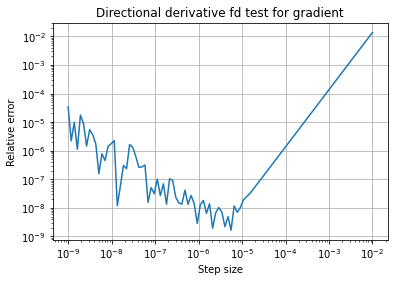

In [20]:
fd_validation.gradConvergencePlot(pw, perturb=direction,epsilons=np.logspace(-9, -2, 100))

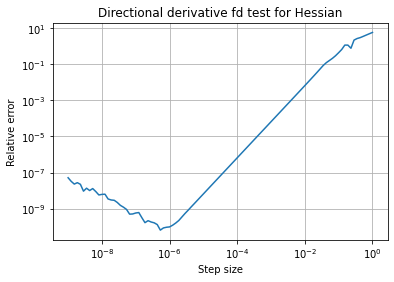

In [21]:
fd_validation.hessConvergencePlot(pw, perturb=direction, epsilons=np.logspace(-9, 0, 100))